In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import joblib

In [2]:
df = pd.read_excel(
    "E Commerce Dataset.xlsx",
    sheet_name="E Comm"
)

df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [3]:
print(df.shape)

df.info()

(5630, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberO

In [11]:
df.isnull().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [5]:
df_clean = df.copy()

numeric_cols = df_clean.select_dtypes(
    include=['int64','float64']
).columns

for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(
        df_clean[col].median()
    )

df_clean.isnull().sum()

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [6]:
df_clean.duplicated().sum()

np.int64(0)

In [7]:
df_clean.duplicated().sum()

np.int64(0)

In [10]:
churn_rate = (
    df_clean['Churn'].sum()
    /
    len(df_clean)
) * 100

print("Churn Rate:", round(churn_rate,2), "%")

Churn Rate: 16.84 %


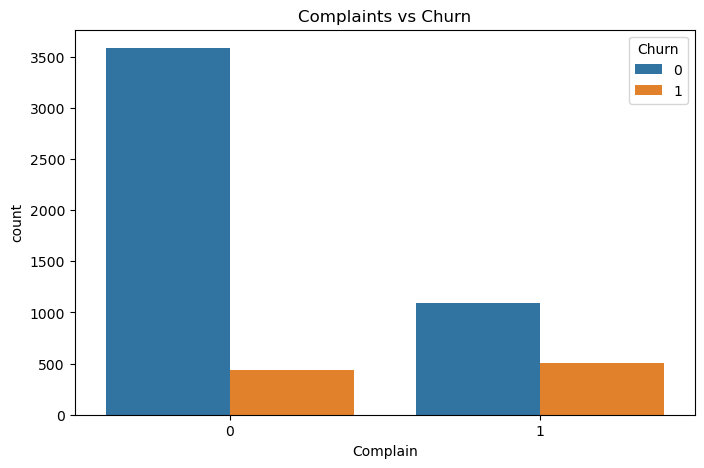

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Complain',
    hue='Churn',
    data=df_clean
)

plt.title("Complaints vs Churn")
plt.show()

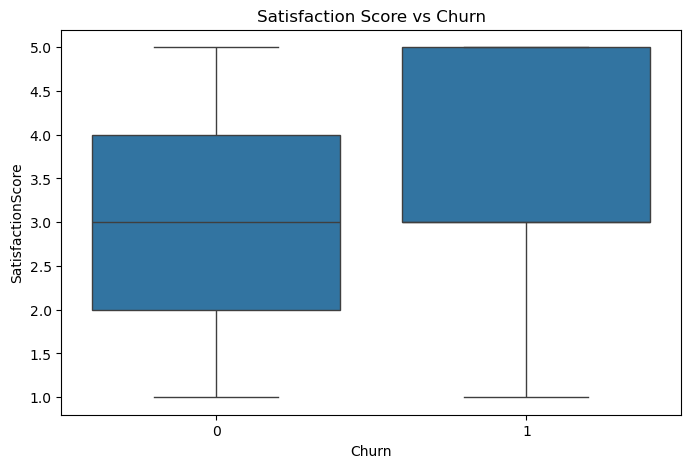

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='SatisfactionScore',
    data=df_clean
)

plt.title("Satisfaction Score vs Churn")
plt.show()

In [14]:
df_ml = df_clean.copy()

for col in df_ml.columns:
    if df_ml[col].dtype == 'object':
        le = LabelEncoder()
        df_ml[col] = le.fit_transform(df_ml[col])

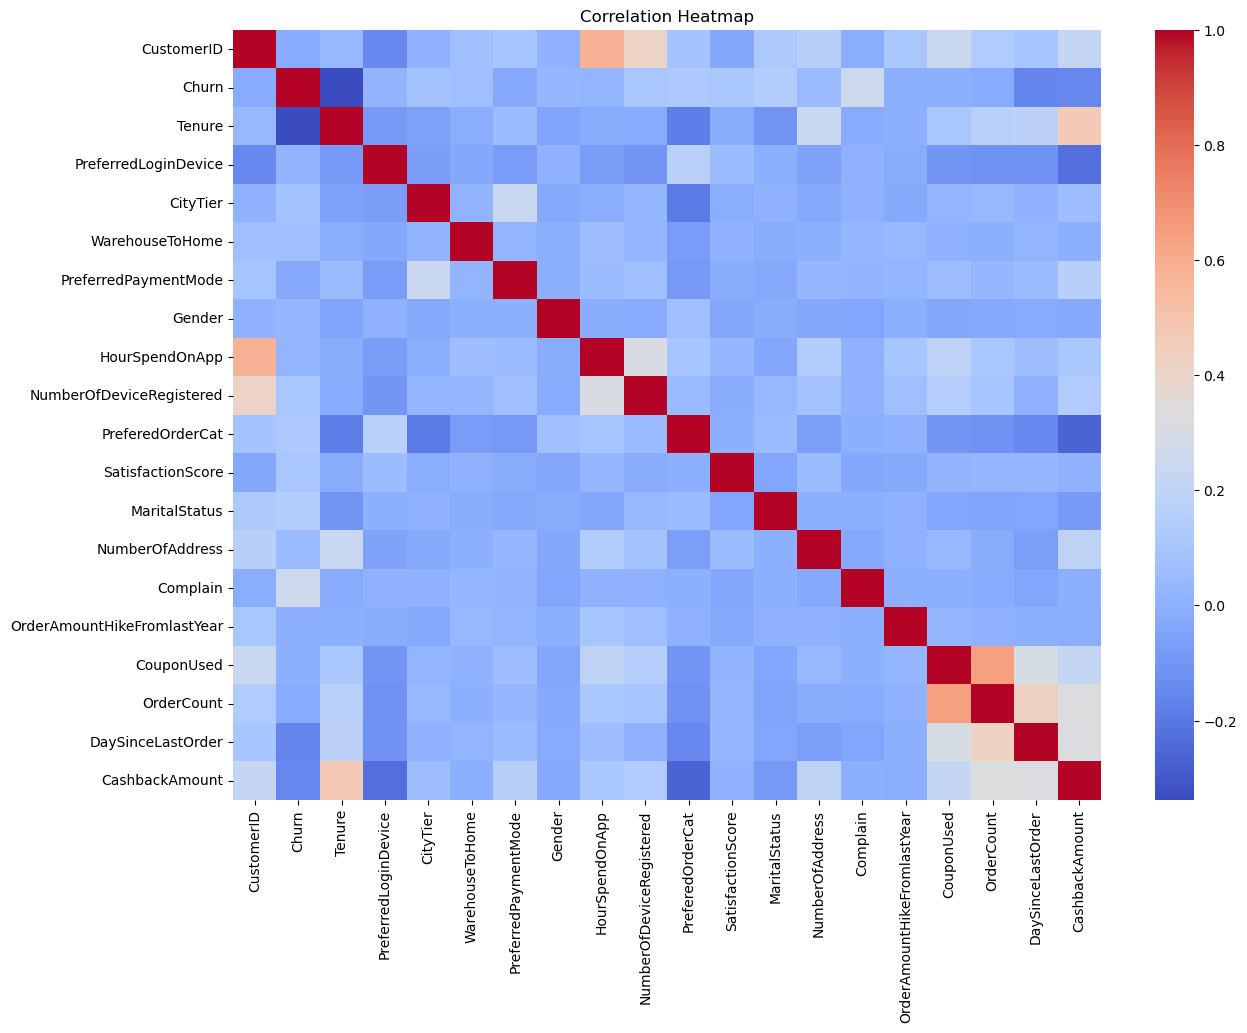

In [15]:
corr = df_ml.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [16]:
corr['Churn'].sort_values(
    ascending=False
)

Churn                          1.000000
Complain                       0.250188
MaritalStatus                  0.140316
PreferedOrderCat               0.118922
NumberOfDeviceRegistered       0.107939
SatisfactionScore              0.105481
CityTier                       0.084703
WarehouseToHome                0.069544
NumberOfAddress                0.043931
Gender                         0.029264
HourSpendOnApp                 0.018816
PreferredLoginDevice           0.013281
CouponUsed                    -0.001430
OrderAmountHikeFromlastYear   -0.007075
CustomerID                    -0.019083
OrderCount                    -0.024038
PreferredPaymentMode          -0.026519
CashbackAmount                -0.154118
DaySinceLastOrder             -0.155871
Tenure                        -0.337831
Name: Churn, dtype: float64

In [17]:
df_ml = df_ml.drop(
    'CustomerID',
    axis=1
)

X = df_ml.drop(
    'Churn',
    axis=1
)

y = df_ml['Churn']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(
    X_test
)

lr_acc = accuracy_score(
    y_test,
    lr_pred
)

print("Logistic Regression:", lr_acc)

Logistic Regression: 0.8712255772646537


In [20]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

dt_pred = dt.predict(
    X_test
)

dt_acc = accuracy_score(
    y_test,
    dt_pred
)

print("Decision Tree:", dt_acc)

Decision Tree: 0.9644760213143873


In [21]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest:", rf_acc)

Random Forest: 0.9804618117229129


In [22]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        lr_acc,
        dt_acc,
        rf_acc
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.871226
1,Decision Tree,0.964476
2,Random Forest,0.980462


In [23]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       936
           1       0.98      0.90      0.94       190

    accuracy                           0.98      1126
   macro avg       0.98      0.95      0.96      1126
weighted avg       0.98      0.98      0.98      1126



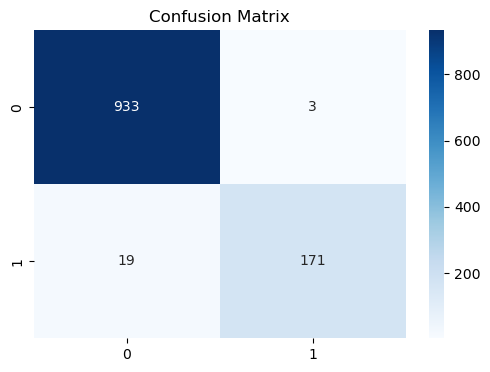

In [24]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.show()

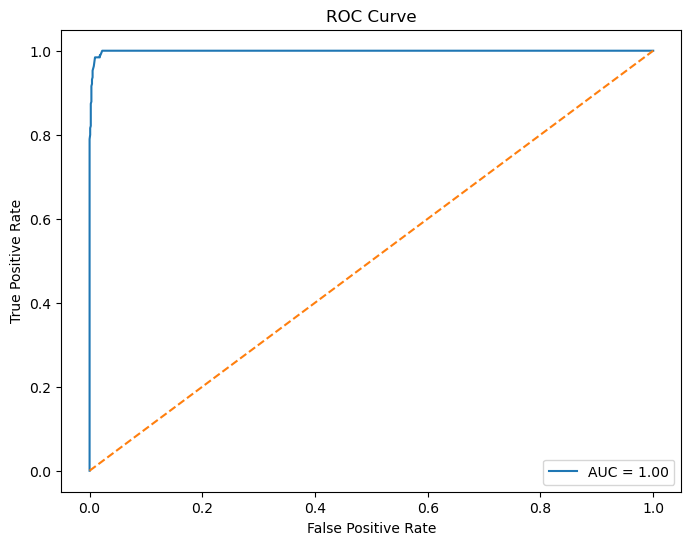

In [25]:
rf_probs = rf_model.predict_proba(
    X_test
)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_probs
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [26]:
feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance':
    rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,Tenure,0.220901
17,CashbackAmount,0.104030
3,WarehouseToHome,0.071645
12,Complain,0.065949
11,NumberOfAddress,0.064535
16,DaySinceLastOrder,0.063123
13,OrderAmountHikeFromlastYear,0.058647
9,SatisfactionScore,0.050047
4,PreferredPaymentMode,0.043330
8,PreferedOrderCat,0.040890


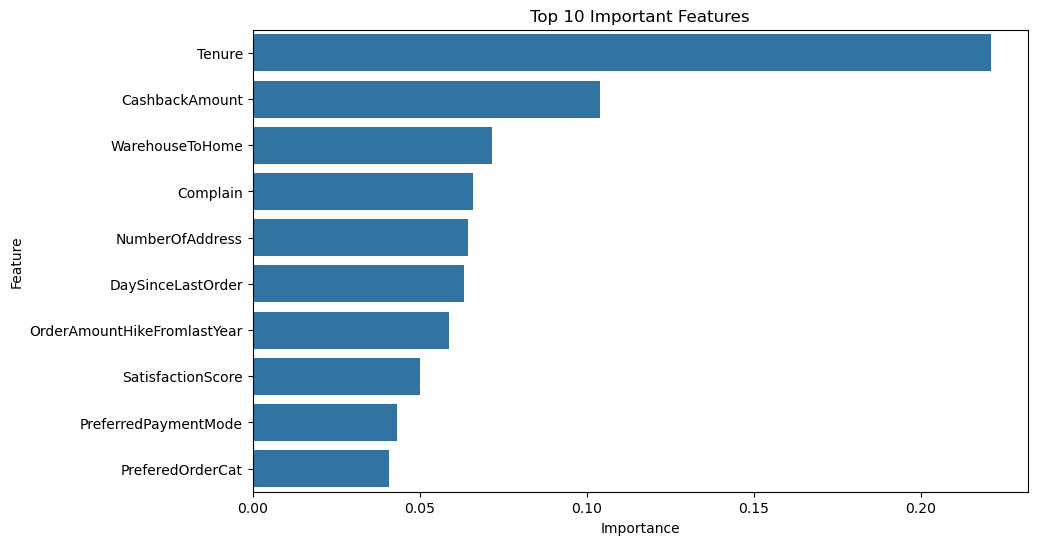

In [27]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

In [28]:
df_results = df_clean.copy()

df_results['Predicted_Churn'] = rf_model.predict(X)

df_results['Churn_Probability'] = rf_model.predict_proba(X)[:,1]

df_results.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,...,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Predicted_Churn,Churn_Probability
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,...,Single,9,1,11.0,1.0,1.0,5.0,159.93,1,0.72
1,50002,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,...,Single,7,1,15.0,0.0,1.0,0.0,120.90,1,0.82
2,50003,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,...,Single,6,1,14.0,0.0,1.0,3.0,120.28,1,0.96
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,...,Single,8,0,23.0,0.0,1.0,3.0,134.07,1,0.88
4,50005,1,0.0,Phone,1,12.0,CC,Male,3.0,3,...,Single,3,0,11.0,1.0,1.0,3.0,129.60,1,0.89


In [29]:
def risk_level(prob):

    if prob >= 0.7:
        return "High Risk"

    elif prob >= 0.4:
        return "Medium Risk"

    else:
        return "Low Risk"

df_results['Risk_Level'] = df_results[
    'Churn_Probability'
].apply(risk_level)

In [30]:
df_results.to_csv(
    "Customer_Churn_Final.csv",
    index=False
)

print(
    "Customer_Churn_Final.csv Saved Successfully"
)

Customer_Churn_Final.csv Saved Successfully


In [31]:
joblib.dump(
    rf_model,
    "model.pkl"
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully
